# Veri Yükleme ve İlk İnceleme

### kullanılıcak kütüphanelerin tanımlanması

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["figure.dpi"] = 100

## 1-Veri seti yükleme

In [63]:
df = pd.read_csv("proje_dataset2.csv")

# 2-İlk ve son 5 satırı görüntüleme

In [64]:
df.head()

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
0,TOSHIBA,Ultra HD LED,55,37999,54990,VIDAA,4.3
1,TCL,QLED Ultra HD,55,52999,129990,Android,4.4
2,realme,HD LED,32,13999,17999,Android,4.3
3,Mi,HD LED,32,14999,19999,Android,4.4
4,realme,HD LED,32,12999,21999,Android,4.3


In [65]:
df[-5:]

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
907,SONY,Full HD LED,43,44999,57900,Linux,4.4
908,SONY,Full HD LED,40,41499,51900,Linux,4.6
909,SONY,Ultra HD LED,65,149990,184990,Linux,4.3
910,SONY,HD LED,32,32900,32900,Linux,4.4
911,SONY,Full HD LED,43,56900,56900,Linux,4.6


## 3-Sütün isimlerini ve veri tiplerinin listelemesi

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             912 non-null    object 
 1   Resolution        912 non-null    object 
 2   Size              912 non-null    int64  
 3   Selling Price     912 non-null    int64  
 4   Original Price    912 non-null    int64  
 5   Operating System  901 non-null    object 
 6   Rating            692 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 50.0+ KB


## 4-temel istatistikler

In [67]:
df.describe()

,Size,Selling Price,Original Price,Rating
count,912.000000,912.000000,912.000000,692.000000
mean,45.942982,59358.606360,81975.213816,4.234104
std,12.316492,65866.677856,84823.568826,0.366694
min,17.000000,4849.000000,6999.000000,2.000000
25%,32.000000,19797.500000,28990.000000,4.100000
50%,43.000000,36990.000000,52900.000000,4.300000
75%,55.000000,67064.250000,99900.000000,4.400000
max,85.000000,499990.000000,549990.000000,5.000000


# Veri Temizleme

## 1-Eksik değerleri ve sayıları

In [68]:
for col in df.columns:
    print (f"{col} sütunundaki eksik değer sayısı: {df[col].isnull().sum()}")
print(f"\nToplam eksik değer sayısı: {df.isnull().sum().sum()}")

Brand sütunundaki eksik değer sayısı: 0
Resolution sütunundaki eksik değer sayısı: 0
Size  sütunundaki eksik değer sayısı: 0
Selling Price sütunundaki eksik değer sayısı: 0
Original Price sütunundaki eksik değer sayısı: 0
Operating System sütunundaki eksik değer sayısı: 11
Rating sütunundaki eksik değer sayısı: 220

Toplam eksik değer sayısı: 231


## 2-Tekrarlayan satır kontrolü ve silme

In [69]:
df[df.duplicated()]

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
214,LG,Ultra HD LED,43,43599,59990,WebOS,NaN
360,Candes,Full HD LED,40,15999,29990,Android,4.1
373,Candes,HD LED,24,9999,17990,Android,4.1
377,Candes,Full HD LED,40,15999,29990,Android,4.1
434,Candes,Full HD LED,40,15999,29990,Android,4.1
496,Candes,HD LED,24,9999,17990,Android,4.1
498,T-Series,HD LED,40,19999,28990,Android,NaN
501,T-Series,HD LED,40,19999,28990,Android,NaN
540,TCL,Ultra HD LED,50,33999,62990,Android,4.4
634,Candes,Full HD LED,40,15999,29990,Android,4.1


In [70]:
tekrarsız_df = df.drop_duplicates()
tekrarsız_df.duplicated().sum()

np.int64(0)

In [71]:
df = tekrarsız_df

# Eksik Veri Doldurma

## 1-Operating System sütunu için

In [72]:

enCokGecenOs = df["Operating System"].value_counts().index[0]

df["Operating System"] = df["Operating System"].fillna(enCokGecenOs)

    

## 2-Rating sütunu için

In [73]:

df_gecici = df.copy()

essiz_marka = df_gecici["Brand"].unique()

for marka in essiz_marka:
   
    marka_filtre = df_gecici["Brand"] == marka
    df_filtreli = df_gecici[marka_filtre]

    ortalama = np.round(np.mean(df_filtreli["Rating"]), 2)

    if ~np.isnan(ortalama):  

        df_filtreli["Rating"] = df_filtreli["Rating"].fillna(ortalama)
    else:  
        tum_ortalama = np.round(np.mean(df_gecici["Rating"]), 2)
        df_filtreli["Rating"] = df_filtreli["Rating"].fillna(tum_ortalama)

    
    df_gecici[marka_filtre] = df_filtreli


df = df_gecici.copy()


# Özellik Mühendisliği

# İndirim yüzdesi sütunu oluşturma

In [74]:
df["Discount Percentage"] = np.round(((df["Original Price"] - df["Selling Price"]) / df["Original Price"] * 100), 2)

## Fiyat Kategori sütunu oluşturma

In [75]:
kategori_listesi = []

for fiyat in df["Selling Price"]:
    if fiyat < 20000:
        kategori_listesi.append("Ekonomik")
    elif fiyat < 50000:
        kategori_listesi.append("Orta Segment")
    elif fiyat < 100000:
        kategori_listesi.append("Premium")
    else:
        kategori_listesi.append("Ultra Premium")

df["Price Category"] = kategori_listesi

# Veri Görselleştirme

### a) popüler 10 marka Grafiği

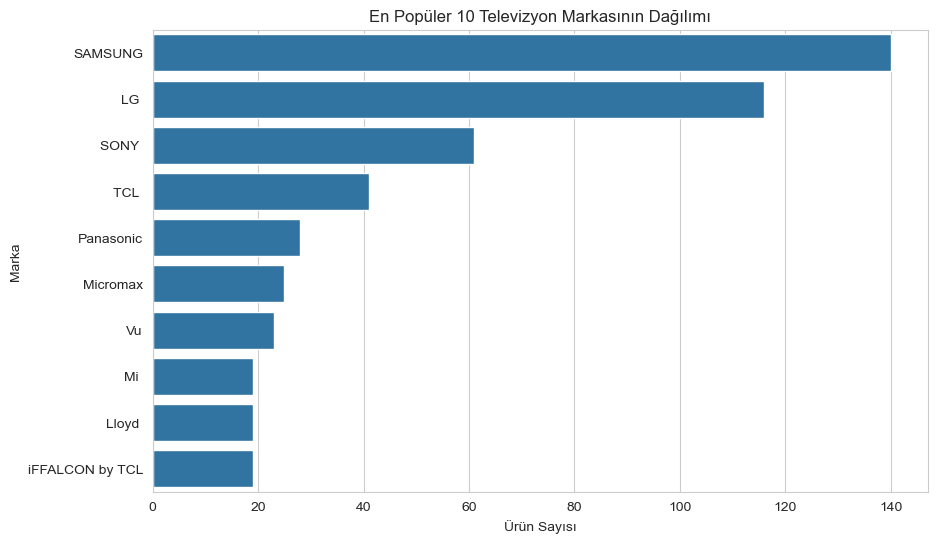

In [76]:

top_10_markalar = df["Brand"].value_counts().head(10).index


veri_top10 = df[df["Brand"].isin(top_10_markalar)]

plt.figure(figsize=(10, 6))
sns.countplot(
    data=veri_top10,
    y="Brand",
    order=top_10_markalar
)

plt.title("En Popüler 10 Televizyon Markasının Dağılımı")
plt.xlabel("Ürün Sayısı")
plt.ylabel("Marka")
plt.show()



### b) en pahalı 10 ortalama satış fiyatı grafiği

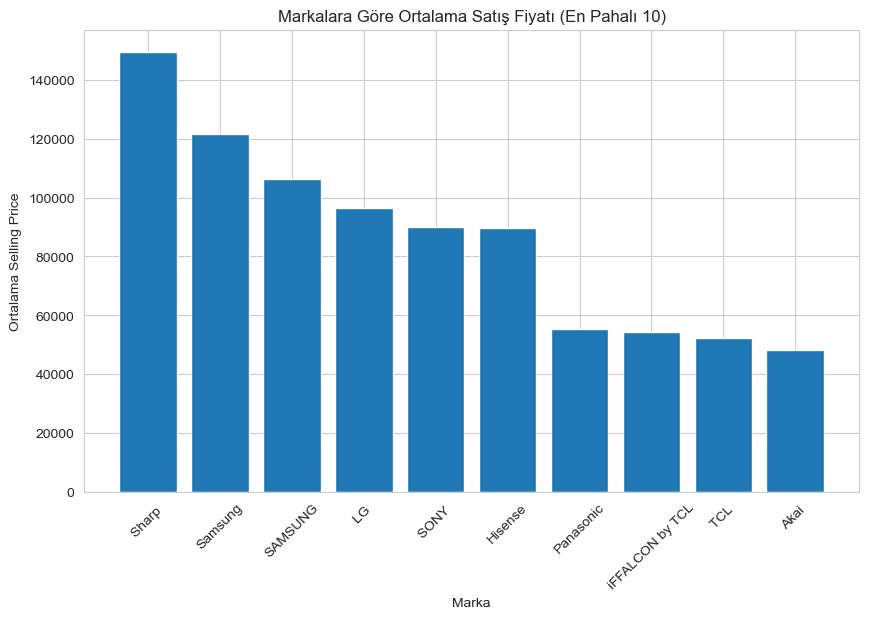

In [77]:
markalar = df["Brand"].unique()

marka_ortalama_fiyat = {}

# Her marka için ortalama satış fiyatını hesapla
for m in markalar:
    filtre = df["Brand"] == m
    ortalama_fiyat = df[filtre]["Selling Price"].mean()
    
    if not pd.isna(ortalama_fiyat):
        marka_ortalama_fiyat[m] = ortalama_fiyat

# Ortalama fiyata göre azalan sırala ve en pahalı 10 markayı seç
en_pahali_10 = sorted(
    marka_ortalama_fiyat.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

# Grafik için ayır
marka_isimleri = [i[0] for i in en_pahali_10]
ortalama_fiyatlar = [i[1] for i in en_pahali_10]

# Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(marka_isimleri, ortalama_fiyatlar)
plt.title("Markalara Göre Ortalama Satış Fiyatı (En Pahalı 10)")
plt.xlabel("Marka")
plt.ylabel("Ortalama Selling Price")
plt.xticks(rotation=45)
plt.show()

### c) ortalama rating değeri en yüksek 10 marka grafiği

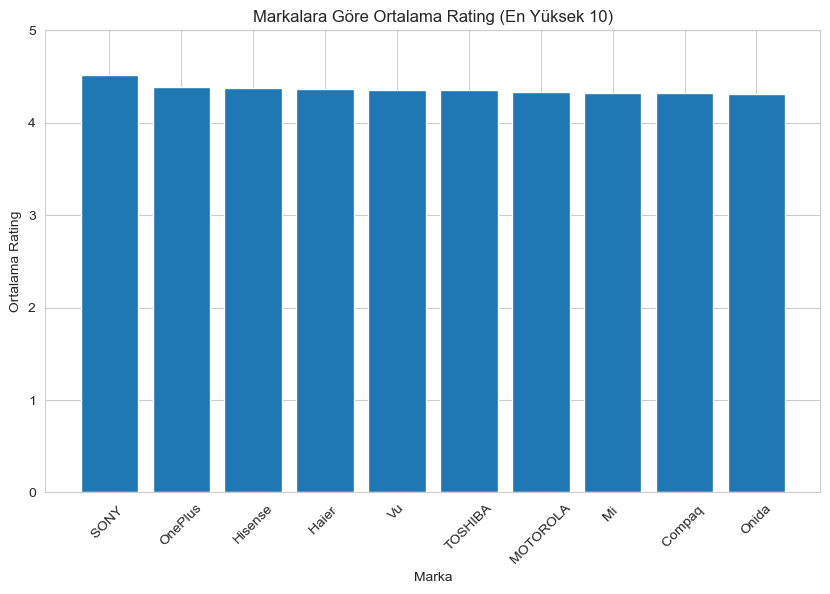

In [78]:
markalar = df["Brand"].unique()

marka_ortalama_rating = {}

# Her marka için ortalama rating hesapla
for m in markalar:
    filtre = df["Brand"] == m
    ortalama_rating = df[filtre]["Rating"].mean()
    
    if not pd.isna(ortalama_rating):
        marka_ortalama_rating[m] = ortalama_rating

# Ortalama ratinge göre büyükten küçüğe sırala ve ilk 10'u al
en_yuksek_10 = sorted(
    marka_ortalama_rating.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

# Grafik için verileri ayır
marka_isimleri = [i[0] for i in en_yuksek_10]
ortalama_ratingler = [i[1] for i in en_yuksek_10]

# Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(marka_isimleri, ortalama_ratingler)
plt.title("Markalara Göre Ortalama Rating (En Yüksek 10)")
plt.xlabel("Marka")
plt.ylabel("Ortalama Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5)  # Rating aralığı genelde 0–5
plt.show()

### d) ekran boyutu histogram grafiği

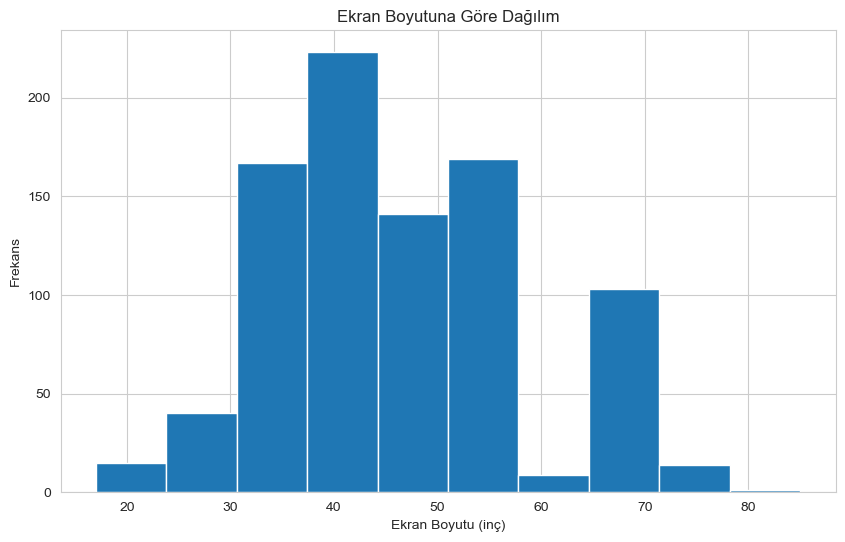

In [81]:
ekran_boyutu = df["Size "].dropna()

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(ekran_boyutu, bins=10)
plt.title("Ekran Boyutuna Göre Dağılım")
plt.xlabel("Ekran Boyutu (inç)")
plt.ylabel("Frekans")
plt.show()

In [83]:
df.to_csv("proje_dataset2_sonHal.csv", index=False)